# Module 0 — La *sandbox* : carnet d'ordres + simulateur + interface bot

**Objectif pédagogique.** Construire, étape par étape, le socle de tout market-maker :

1. Un **carnet d'ordres** (`OrderBook`) — la structure de données du marché.
2. Un **simulateur de marché** — un « vrai prix » qui bouge + des *noise traders*.
3. Une **interface bot** standardisée `on_market_update(state) -> quotes` — le pattern que tu retrouveras dans le SDK d'Akuna.

> Chaque section a une **cellule de théorie** (markdown) puis une **cellule de code testable**. Exécute-les dans l'ordre (Shift+Entrée) et lis les `print` : ils sont là pour que tu *voies* ce qui se passe.

Aucune dépendance externe n'est requise pour le cœur (Python pur). `matplotlib` n'est utilisé qu'à la toute fin pour un graphe — et le notebook tourne même sans lui.


## 0. Imports & graine aléatoire

On fixe la graine (`seed`) pour que tes résultats soient **reproductibles** : deux exécutions donnent les mêmes nombres aléatoires. Indispensable pour déboguer.


In [1]:
import random
import math
from dataclasses import dataclass, field
from collections import deque

random.seed(42)  # reproductibilite : enleve cette ligne pour du vrai alea
print('Setup OK')


Setup OK


## 1. Théorie express — le carnet d'ordres

Un carnet a **deux côtés** :
- **Bids** (achats) : prix où des gens veulent *acheter*, triés du plus haut au plus bas.
- **Asks** (ventes) : prix où des gens veulent *vendre*, triés du plus bas au plus haut.

Prix clés :
- **Best bid** = meilleur achat (le plus haut). **Best ask** = meilleure vente (le plus bas).
- **Mid** = (best bid + best ask) / 2 → estimation naïve de la « vraie » valeur.
- **Spread** = best ask − best bid → ce que capte le market-maker.

```
ASKS    100.20  x150
        100.10  x80      <- best ask
        --------------
        99.90   x100     <- best bid
BIDS    99.80   x200
```

- Mid = (99.90 + 100.10)/2 = **100.00**, Spread = **0.20**.

**Règle de matching : price-time priority.** On sert d'abord le meilleur prix ; à prix égal, le premier arrivé (priorité de file FIFO). Poster tôt à un bon prix = être devant dans la queue.


## 2. La classe `OrderBook`

On modélise un ordre par un petit objet, puis le carnet par **deux dictionnaires** `prix -> file (deque) d'ordres`.
Une `deque` (file) conserve naturellement la **priorité temps** : on ajoute à droite, on sert à gauche.

Méthodes demandées par la roadmap :
- `add_limit_order(side, price, qty)` → pose un ordre limite, renvoie son `id`.
- `cancel(order_id)` → retire un ordre.
- `match_market_order(side, qty)` → un ordre marché consomme la liquidité du côté opposé.

Plus les lectures utiles : `best_bid`, `best_ask`, `mid`, `spread`.


In [2]:
@dataclass
class Order:
    """Un ordre limite dans le carnet."""
    id: int
    side: str      # 'bid' (achat) ou 'ask' (vente)
    price: float
    qty: int
    owner: str = 'noise'   # qui a poste l'ordre : 'noise' ou 'bot'


class OrderBook:
    def __init__(self):
        # prix -> deque d'Order (FIFO = priorite temps)
        self.bids = {}
        self.asks = {}
        self._next_id = 0
        # index id -> (side, price) pour annuler en O(1) la recherche du niveau
        self._index = {}

    # ---- ecriture ---------------------------------------------------
    def add_limit_order(self, side, price, qty, owner='noise'):
        assert side in ('bid', 'ask')
        price = round(price, 2)
        oid = self._next_id
        self._next_id += 1
        book = self.bids if side == 'bid' else self.asks
        book.setdefault(price, deque()).append(Order(oid, side, price, qty, owner))
        self._index[oid] = (side, price)
        return oid

    def cancel(self, order_id):
        info = self._index.pop(order_id, None)
        if info is None:
            return False  # deja execute ou inexistant
        side, price = info
        book = self.bids if side == 'bid' else self.asks
        level = book.get(price)
        if not level:
            return False
        for o in list(level):
            if o.id == order_id:
                level.remove(o)
                break
        if not level:
            del book[price]
        return True

    # ---- lecture ----------------------------------------------------
    def best_bid(self):
        return max(self.bids) if self.bids else None

    def best_ask(self):
        return min(self.asks) if self.asks else None

    def mid(self):
        b, a = self.best_bid(), self.best_ask()
        if b is None or a is None:
            return None
        return (b + a) / 2

    def spread(self):
        b, a = self.best_bid(), self.best_ask()
        if b is None or a is None:
            return None
        return a - b

    def volume_at(self, side, price):
        book = self.bids if side == 'bid' else self.asks
        return sum(o.qty for o in book.get(round(price, 2), ()))

    # ---- matching ---------------------------------------------------
    def match_market_order(self, side, qty):
        """Un ordre MARCHE de 'qty' unites.
        side='buy'  -> achete -> consomme les ASKS du moins cher au plus cher.
        side='sell' -> vend   -> consomme les BIDS du plus cher au plus bas.
        Renvoie la liste des fills : [(order_id, owner, price, qty_filled), ...].
        """
        assert side in ('buy', 'sell')
        fills = []
        remaining = qty
        if side == 'buy':
            book, price_order = self.asks, sorted(self.asks)              # croissant
        else:
            book, price_order = self.bids, sorted(self.bids, reverse=True)  # decroissant
        for price in price_order:
            if remaining <= 0:
                break
            level = book[price]
            while level and remaining > 0:
                o = level[0]                 # priorite temps : premier de la file
                take = min(o.qty, remaining)
                fills.append((o.id, o.owner, price, take))
                o.qty -= take
                remaining -= take
                if o.qty == 0:               # ordre entierement consomme
                    level.popleft()
                    self._index.pop(o.id, None)
            if not level:
                del book[price]
        return fills

    def __repr__(self):
        lines = ['ASKS']
        for p in sorted(self.asks, reverse=True):
            lines.append(f'        {p:>7.2f}  x{self.volume_at("ask", p)}')
        lines.append('        --------------')
        for p in sorted(self.bids, reverse=True):
            lines.append(f'        {p:>7.2f}  x{self.volume_at("bid", p)}')
        lines.append('BIDS')
        return '\n'.join(lines)

print('Classe OrderBook definie')


Classe OrderBook definie


### 2.0 Démo : *voir* la structure bouger

Avant de tester les prix, regardons **l'intérieur des dictionnaires**. Cette cellule pose des fiches, déclenche un ordre marché, annule une fiche — et **affiche le contenu réel** du carnet après chaque geste.

Lis bien le niveau `99.90` : deux ordres au même prix s'empilent dans une **file** `[ #0 -> #1 ]`. Le `#0` (arrivé en premier) est à **gauche** = servi en premier. C'est ça, la priorité **prix-temps**.


In [3]:
# Petit utilitaire pour AFFICHER l'interieur des dictionnaires du carnet.
# Objectif : voir la structure "prix -> file d'ordres" bouger a chaque geste.

def montre(book, titre):
    print(f'=== {titre} ===')
    # asks = dict {prix: deque d'Order}. On les trie du plus haut au plus bas.
    print('  ASKS (vendeurs) :')
    for prix in sorted(book.asks, reverse=True):
        file = book.asks[prix]                      # la deque a ce prix
        fiches = ' -> '.join(f'#{o.id}(x{o.qty})' for o in file)  # de gauche a droite
        print(f'    {prix:7.2f} : [ {fiches} ]')
    print('  BIDS (acheteurs) :')
    for prix in sorted(book.bids, reverse=True):
        file = book.bids[prix]
        fiches = ' -> '.join(f'#{o.id}(x{o.qty})' for o in file)
        print(f'    {prix:7.2f} : [ {fiches} ]')
    print()


demo = OrderBook()

# --- GESTE 1 : add_limit_order -> on pose des fiches ---------------------
# Deux acheteurs au MEME prix 99.90 : on verra qu'ils s'empilent dans la file.
demo.add_limit_order('bid', 99.90, 100)   # fiche #0 (arrive en 1er)
demo.add_limit_order('bid', 99.90, 50)    # fiche #1 (arrive apres, va a droite)
demo.add_limit_order('bid', 99.80, 200)   # fiche #2, autre niveau de prix
demo.add_limit_order('ask', 100.10, 80)   # fiche #3, cote vente
montre(demo, 'apres 4 add_limit_order')
# -> Regarde le niveau 99.90 : [ #0(x100) -> #1(x50) ]
#    #0 est a GAUCHE = premier arrive = premier servi (priorite temps / FIFO).

# --- GESTE 2 : match_market_order -> on consomme depuis la GAUCHE --------
# Quelqu'un VEND 120 au marche -> ca tape les BIDS, meilleur prix d'abord (99.90).
# 100 partent de #0 (vide la fiche), puis 20 de #1.
fills = demo.match_market_order('sell', 120)
print('Fills (qui a ete servi) :', fills)
montre(demo, 'apres un sell marche de 120')
# -> #0 a disparu (entierement consomme), #1 est passe de 50 a 30.
#    La file est "servie a gauche" : exactement la priorite temps.

# --- GESTE 3 : cancel -> on retire une fiche par son id -----------------
demo.cancel(2)   # on annule l'ordre #2 (le bid 99.80 x200)
montre(demo, 'apres cancel(#2)')
# -> le niveau 99.80 a disparu du dictionnaire (plus aucune fiche dessus).


=== apres 4 add_limit_order ===
  ASKS (vendeurs) :
     100.10 : [ #3(x80) ]
  BIDS (acheteurs) :
      99.90 : [ #0(x100) -> #1(x50) ]
      99.80 : [ #2(x200) ]

Fills (qui a ete servi) : [(0, 'noise', 99.9, 100), (1, 'noise', 99.9, 20)]
=== apres un sell marche de 120 ===
  ASKS (vendeurs) :
     100.10 : [ #3(x80) ]
  BIDS (acheteurs) :
      99.90 : [ #1(x30) ]
      99.80 : [ #2(x200) ]

=== apres cancel(#2) ===
  ASKS (vendeurs) :
     100.10 : [ #3(x80) ]
  BIDS (acheteurs) :
      99.90 : [ #1(x30) ]



### 2.1 Test chiffré — on rejoue l'exemple de la roadmap

On construit exactement le carnet de l'exemple et on **vérifie** mid = 100.00 et spread = 0.20.
C'est ton premier réflexe d'ingénieur quant : *toute brique se valide par un test chiffré*.


In [4]:
book = OrderBook()
book.add_limit_order('ask', 100.20, 150)
book.add_limit_order('ask', 100.10, 80)
book.add_limit_order('bid', 99.90, 100)
book.add_limit_order('bid', 99.80, 200)

print(book)
print()
print(f'best_bid = {book.best_bid()}')
print(f'best_ask = {book.best_ask()}')
print(f'mid      = {book.mid()}')
print(f'spread   = {book.spread():.2f}')

assert book.mid() == 100.00, 'mid attendu = 100.00'
assert round(book.spread(), 2) == 0.20, 'spread attendu = 0.20'
print('\nOK : mid=100.00 et spread=0.20 comme dans la roadmap.')


ASKS
         100.20  x150
         100.10  x80
        --------------
          99.90  x100
          99.80  x200
BIDS

best_bid = 99.9
best_ask = 100.1
mid      = 100.0
spread   = 0.20

OK : mid=100.00 et spread=0.20 comme dans la roadmap.


### 2.2 Test chiffré — un ordre marché consomme la liquidité

Un **achat marché de 50** doit lever 50 unités au best ask (100.10). Vérifions le fill et l'état résultant du carnet (il reste 30 à 100.10).


In [5]:
fills = book.match_market_order('buy', 50)
print('Fills :', fills)        # [(order_id, owner, price, qty)]
print()
print(book)

assert fills == [(1, 'noise', 100.10, 50)]
assert book.volume_at('ask', 100.10) == 30   # 80 - 50
print('\nOK : 50 leves a 100.10, il reste 30 a ce niveau.')


Fills : [(1, 'noise', 100.1, 50)]

ASKS
         100.20  x150
         100.10  x30
        --------------
          99.90  x100
          99.80  x200
BIDS

OK : 50 leves a 100.10, il reste 30 a ce niveau.


## 3. Le simulateur de marché

On veut un marché *vivant* contre lequel tester un bot. Deux ingrédients :

1. **Un « vrai prix » (`true_price`)** qui suit une **marche aléatoire** (random walk) :
   `true_price ← true_price + σ · ε`, avec `ε ~ N(0,1)`. Personne ne le connaît directement ; le carnet *l'estime* bruitévement.
2. **Des *noise traders*** :
   - des **makers** qui posent des ordres limites autour du vrai prix (ils créent la liquidité = le carnet) ;
   - des **takers** qui envoient des ordres marché aléatoires (achat/vente) et *consomment* la liquidité.

À chaque *tick* on : (a) avance le vrai prix, (b) régénère un peu de liquidité de fond, (c) laisse le bot coter, (d) déclenche quelques ordres marché. Les fills sur les ordres du bot lui sont attribués via `owner='bot'`.


In [6]:
def seed_liquidity(book, true_price, n_levels=5, tick=0.05, base_qty=100, noise=0.02):
    """Pose des ordres limites 'noise' de part et d'autre du vrai prix.
    Cree un carnet realiste : plusieurs niveaux de chaque cote.
    """
    for i in range(1, n_levels + 1):
        # bid de plus en plus bas, ask de plus en plus haut
        bid_p = true_price - i * tick - random.uniform(0, noise)
        ask_p = true_price + i * tick + random.uniform(0, noise)
        q_bid = max(1, int(base_qty * random.uniform(0.5, 1.5)))
        q_ask = max(1, int(base_qty * random.uniform(0.5, 1.5)))
        book.add_limit_order('bid', bid_p, q_bid, owner='noise')
        book.add_limit_order('ask', ask_p, q_ask, owner='noise')


def noise_takers(book, n_orders=3, max_qty=60):
    """Envoie quelques ordres marche aleatoires. Renvoie tous les fills."""
    all_fills = []
    for _ in range(n_orders):
        side = random.choice(['buy', 'sell'])
        qty = random.randint(1, max_qty)
        all_fills += book.match_market_order(side, qty)
    return all_fills

print('Simulateur (seed_liquidity, noise_takers) defini')


Simulateur (seed_liquidity, noise_takers) defini


## 4. L'interface bot standardisée

Le pattern clé : **le bot reçoit un état de marché, renvoie des cotations.** Exactement ce que fera le SDK d'Akuna (`à chaque tick → renvoie tes quotes`).

```
on_market_update(state) -> [ (side, price, qty), ... ]
```

On code une classe de base `Bot`, puis un **baseline ultra-simple** (`NaiveMMBot`, le futur Module 1) : il cote symétriquement autour du mid avec un demi-spread fixe `delta`. Le bot suit aussi son **inventaire** `q` et son **cash**, pour mesurer le PnL.

PnL *mark-to-market* = `cash + q · mid` : ton cash plus la valeur liquidative de ton stock au prix courant.


In [7]:
class Bot:
    """Interface commune. Un bot concret redefinit on_market_update()."""
    def __init__(self, name='bot'):
        self.name = name
        self.inventory = 0      # q : positif = long, negatif = short
        self.cash = 0.0

    def on_market_update(self, state):
        """state = dict(best_bid, best_ask, mid, spread).
        Doit renvoyer une liste de cotations (side, price, qty)."""
        raise NotImplementedError

    def on_fill(self, side, price, qty):
        """Appele quand UNE de nos cotations est executee.
        side='bid' -> on a ACHETE qty a price ; side='ask' -> on a VENDU."""
        if side == 'bid':
            self.inventory += qty
            self.cash -= price * qty
        else:
            self.inventory -= qty
            self.cash += price * qty

    def pnl(self, mid):
        """Valeur liquidative : cash + valeur du stock au mid courant."""
        return self.cash + self.inventory * mid


class NaiveMMBot(Bot):
    """Baseline (Module 1) : bid = mid - delta, ask = mid + delta, delta fixe."""
    def __init__(self, delta=0.10, qty=20, name='naive'):
        super().__init__(name)
        self.delta = delta
        self.qty = qty

    def on_market_update(self, state):
        mid = state['mid']
        if mid is None:
            return []
        return [
            ('bid', mid - self.delta, self.qty),
            ('ask', mid + self.delta, self.qty),
        ]

print('Bot et NaiveMMBot definis')


Bot et NaiveMMBot definis


## 5. La boucle de simulation (le harness)

On assemble tout. À chaque tick :
1. le vrai prix avance (random walk) ;
2. on reconstruit un carnet de fond (liquidité noise) autour du vrai prix ;
3. le bot lit l'état et **poste ses cotations** (`owner='bot'`) ;
4. des ordres marché aléatoires arrivent → certains touchent le bot → `on_fill` ;
5. on enregistre l'historique (prix, inventaire, PnL) pour analyser après.

> Simplification volontaire pour le Module 0 : on **recrée le carnet à chaque tick** (au lieu de le faire persister). C'est suffisant pour valider la mécanique et mesurer un PnL ; la persistance fine viendra plus tard.


In [8]:
def run_simulation(bot, n_ticks=500, start_price=100.0, sigma=0.05,
                   takers_per_tick=4, seed=42, verbose_first=3):
    random.seed(seed)
    true_price = start_price
    history = {'tick': [], 'true_price': [], 'mid': [],
               'inventory': [], 'pnl': []}

    for t in range(n_ticks):
        # 1) le vrai prix avance
        true_price += sigma * random.gauss(0, 1)

        # 2) carnet de fond
        book = OrderBook()
        seed_liquidity(book, true_price)

        # 3) le bot cote
        state = {'best_bid': book.best_bid(), 'best_ask': book.best_ask(),
                 'mid': book.mid(), 'spread': book.spread()}
        bot_ids = {}   # order_id -> side, pour reconnaitre NOS fills
        for side, price, qty in bot.on_market_update(state):
            oid = book.add_limit_order(side, price, qty, owner='bot')
            bot_ids[oid] = side

        # 4) ordres marche -> fills
        fills = noise_takers(book, n_orders=takers_per_tick)
        for oid, owner, price, qty in fills:
            if owner == 'bot':
                bot.on_fill(bot_ids[oid], price, qty)

        # 5) enregistrement
        mid = state['mid']
        history['tick'].append(t)
        history['true_price'].append(true_price)
        history['mid'].append(mid)
        history['inventory'].append(bot.inventory)
        history['pnl'].append(bot.pnl(mid))

        if t < verbose_first:
            print(f'tick {t}: mid={mid:.2f} inv={bot.inventory:+d} '
                  f'pnl={bot.pnl(mid):+.2f}')

    return history


bot = NaiveMMBot(delta=0.10, qty=20)
hist = run_simulation(bot, n_ticks=500)

final_mid = hist['mid'][-1]
print()
print(f'--- Resultats apres {len(hist["tick"])} ticks ---')
print(f'Inventaire final : {bot.inventory:+d}')
print(f'Cash final       : {bot.cash:+.2f}')
print(f'PnL final (m2m)  : {bot.pnl(final_mid):+.2f}')
print(f'Inventaire max   : {max(abs(x) for x in hist["inventory"])}')


tick 0: mid=100.00 inv=+0 pnl=+0.00
tick 1: mid=99.99 inv=+0 pnl=+0.00
tick 2: mid=99.97 inv=+0 pnl=+0.00

--- Resultats apres 500 ticks ---
Inventaire final : +241
Cash final       : -24204.52
PnL final (m2m)  : +730.54
Inventaire max   : 370


## 6. Quelques métriques (sans dépendance)

On calcule à la main les métriques de la roadmap (Module 7) : PnL final, **Sharpe** (régularité = PnL moyen / écart-type des variations de PnL), et inventaire max. Pur Python, via le module `statistics`.


In [9]:
import statistics

def metrics(history):
    pnl = history['pnl']
    # variations de PnL tick a tick
    dpnl = [pnl[i] - pnl[i-1] for i in range(1, len(pnl))]
    mean = statistics.fmean(dpnl) if dpnl else 0.0
    sd = statistics.pstdev(dpnl) if len(dpnl) > 1 else 0.0
    sharpe = mean / sd if sd > 0 else float('nan')
    return {
        'pnl_final': pnl[-1],
        'sharpe_par_tick': sharpe,
        'inventaire_max': max(abs(x) for x in history['inventory']),
    }

for k, v in metrics(hist).items():
    print(f'{k:18s}: {v:.4f}' if isinstance(v, float) else f'{k:18s}: {v}')


pnl_final         : 730.5450
sharpe_par_tick   : 0.1384
inventaire_max    : 370


## 7. Visualisation (optionnelle — `matplotlib`)

Si `matplotlib` est installé, on trace le PnL et l'inventaire. Sinon, le notebook te le dit poliment et continue (le cœur ne dépend de rien).

> Pour l'installer : `pip install matplotlib` dans ton environnement.


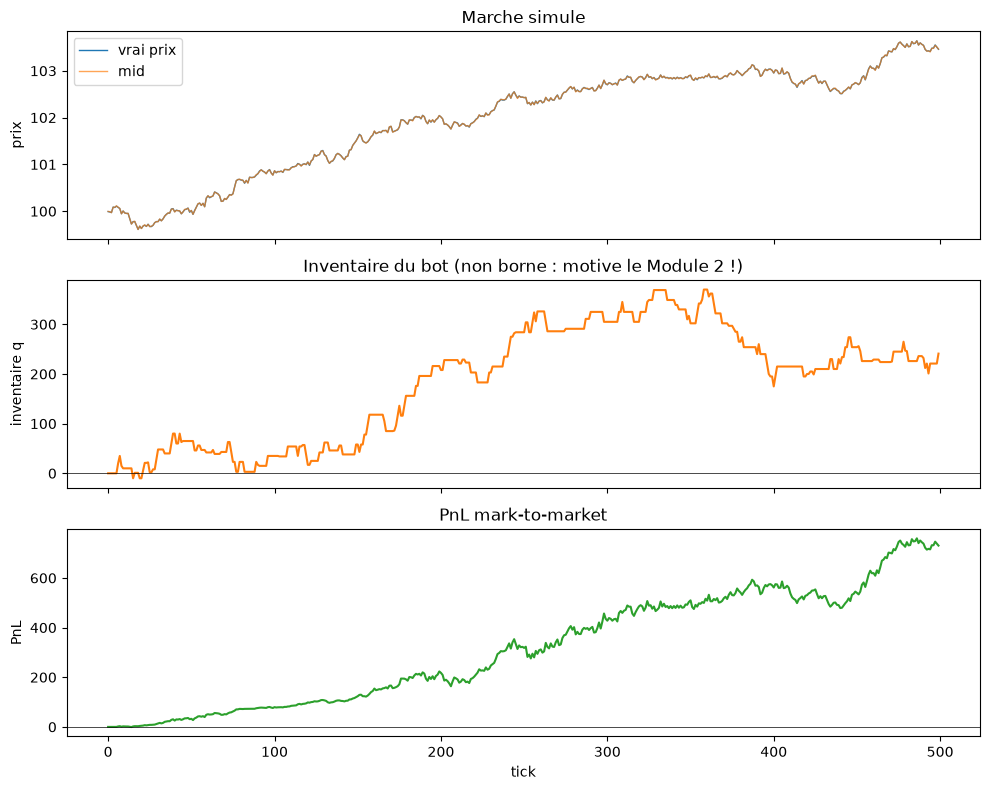

In [10]:
try:
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
    axes[0].plot(hist['tick'], hist['true_price'], label='vrai prix', lw=1)
    axes[0].plot(hist['tick'], hist['mid'], label='mid', lw=1, alpha=0.7)
    axes[0].set_ylabel('prix'); axes[0].legend(); axes[0].set_title('Marche simule')

    axes[1].plot(hist['tick'], hist['inventory'], color='tab:orange')
    axes[1].axhline(0, color='k', lw=0.5)
    axes[1].set_ylabel('inventaire q')
    axes[1].set_title('Inventaire du bot (non borne : motive le Module 2 !)')

    axes[2].plot(hist['tick'], hist['pnl'], color='tab:green')
    axes[2].axhline(0, color='k', lw=0.5)
    axes[2].set_ylabel('PnL'); axes[2].set_xlabel('tick')
    axes[2].set_title('PnL mark-to-market')

    plt.tight_layout()
    plt.show()
except ModuleNotFoundError:
    print('matplotlib non installe -> graphe saute. Installe-le avec : pip install matplotlib')
    print('Apercu texte du PnL (1 point sur 50) :')
    for i in range(0, len(hist['tick']), 50):
        print(f"  tick {hist['tick'][i]:>3}: pnl={hist['pnl'][i]:+7.2f}  inv={hist['inventory'][i]:+d}")


## 8. Ce que tu viens de construire / et après ?

**Acquis (Module 0 + amorce du Module 1).**
- `OrderBook` : add / cancel / match avec priorité **prix-temps**, validé par tests chiffrés.
- Un simulateur : vrai prix en marche aléatoire + makers/takers noise.
- L'interface `on_market_update(state) -> quotes` + suivi inventaire/cash/PnL.
- Un baseline `NaiveMMBot` rentable-ou-pas, **mesurable**.

**Observation clé.** Regarde la courbe d'inventaire : elle **dérive** sans limite. Dès que le prix bouge contre toi avec un gros stock, le PnL souffre. C'est *précisément* le problème que résout le **Module 2 (Avellaneda-Stoikov)** : coter autour d'un prix de réservation qui *skew* selon l'inventaire.

**Pistes pour t'entraîner tout de suite :**
1. Fais varier `delta` (0.05, 0.10, 0.20) et compare PnL / inventaire max / Sharpe.
2. Augmente `sigma` (volatilité) : le baseline tient-il ?
3. Écris un `SkewMMBot` qui décale ses cotations selon `self.inventory` → tu auras amorcé le Module 2.
